# Setup

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import scvi
import scrnatools as rna
import seaborn as sns
import pandas as pd
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
from matplotlib_venn import venn3_unweighted, venn3_circles
import seaborn as sns
import numpy as np
import pickle
import logging
import scipy
from scipy.stats import spearmanr, pearsonr, zscore, ttest_ind
import scanpy as sc
import math
import random
import biomart      

In [4]:
# Set seeds
scvi.settings.seed = 0
scvi.settings.verbosity = logging.WARNING

Global seed set to 0


In [5]:
# Setup figure params
plt.rcParams["pdf.use14corefonts"] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = "Helvetica"
sc.set_figure_params(dpi=80, dpi_save=300, facecolor="white", frameon=False)
sns.set_context("paper")
plt.rcParams["axes.grid"] = False
plt.rcParams['axes.unicode_minus'] = False
cmap = sns.color_palette("colorblind")
# Get the tab20 colormap
tab20_cmap = plt.get_cmap('tab20')

# Create a new colormap without the 7th and 8th colors
colors_to_exclude = [6, 7]  # 0-based index, so 6 and 7 represent the 7th and 8th colors
new_tab20 = [tab20_cmap(i) for i in range(tab20_cmap.N) if i not in colors_to_exclude]

In [6]:
warnings.resetwarnings()

# Import data

Data paths

In [7]:
rawDataPath = "/mnt/iacchus/joe/raw_data/"
processedDataPath = "/mnt/iacchus/joe/processed_data/"

In [8]:
adata = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_TECs_final.h5ad")
model = scvi.model.SCVI.load(
    f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/combined_all_genes",
    adata=adata,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# scVI DE WT vs KO

In [9]:
def scvi_cell_type_de(
    adata, 
    cell_type_key, 
    group_key, condition_group, control_group, 
    min_cells
):
    all_genes = pd.DataFrame()

    for cell_type in adata.obs[cell_type_key].unique():
        subset_data = adata[adata.obs[cell_type_key] == cell_type].copy()
        num_control = sum([i == control_group for i in subset_data.obs[group_key]])
        num_condition = sum([i == condition_group for i in subset_data.obs[group_key]])
        if num_control > min_cells and num_condition > min_cells:
            print(cell_type)
            de_genes = model.differential_expression(
                adata=subset_data,
                groupby=group_key,
                group2=condition_group,
                group1=control_group,
                silent=True,
            )
            de_genes["cell_type"] = cell_type
            all_genes = pd.concat([all_genes, de_genes])
        else:
            print(f"{cell_type} had too few cells in at least one group, skipping")

    all_genes["gene"] = all_genes.index
    all_genes.index = all_genes.index + "_" + all_genes.cell_type
    all_genes = all_genes.sort_index()
    all_genes["abs_lfc"] = abs(all_genes.lfc_mean)
    
    return all_genes

def filter_scvi_de_genes(
    adata, 
    df, 
    bayes_thresh, lfc_thresh, nonzero_thresh, 
    percentile, cell_type_key, expression_layer, peak_expression_thresh, 
    save_path=None,
    ylim=None, *args, **kwargs
):
    for cell_type in df.cell_type.unique():
        expression = rna.tl.get_expression_matrix(
            adata[adata.obs[cell_type_key] == cell_type],
            expression_layer
        )
        percentile_expression = pd.DataFrame(
            np.quantile(expression, percentile, axis=0),
            index=[f"{i}_{cell_type}" for i in expression.columns]
        )
        df.loc[percentile_expression.index, f"expression_{percentile}"] = percentile_expression[0]
    detected_genes = df[df[f"expression_{percentile}"] > peak_expression_thresh].copy()
    detected_genes = detected_genes[
        (detected_genes.non_zeros_proportion1 > nonzero_thresh) |
        (detected_genes.non_zeros_proportion2 > nonzero_thresh)
    ]
    
    ax = plt.scatter(
        x=detected_genes.lfc_mean,
        y=detected_genes.bayes_factor,
        s=1,
        rasterized=True,
        *args, **kwargs
    )
    plt.xlabel("lfc_mean")
    plt.ylabel("bayes_factor")
    plt.axhline(y=bayes_thresh, c="black")
    plt.axvline(x=lfc_thresh, c="black")
    plt.axvline(x=-1*lfc_thresh, c="black")
    if ylim is not None:
        plt.ylim(ylim)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(f"{save_path}", dpi=300)
    plt.show()
    
    filtered_genes = detected_genes[detected_genes.bayes_factor > bayes_thresh].copy()
    filtered_genes = filtered_genes[abs(filtered_genes.lfc_mean) > lfc_thresh]
    
    return detected_genes, filtered_genes

## Run DE

In [10]:
all_genes = {}
for sample in adata.obs["sample"].unique():
    subset_data = adata[adata.obs["sample"] == sample]
    for genotype in ["Aire", "Fezf2"]:
        data = subset_data[subset_data.obs.batch.str.contains(genotype)]
        print(f"{genotype}-{sample}")
        all_gene = scvi_cell_type_de(
            adata=data,
            cell_type_key="subclustered",
            group_key="genotype",
            condition_group=f"{genotype}_KO",
            control_group="WT",
            min_cells=30,
        )
        all_genes[f"{genotype}-{sample}"] = all_gene
        print()

Aire-1
Gut/Liver
Tuft1
Aire-stage
Immature MEC - Ccl21
Mcell
Tuft2
Ciliated had too few cells in at least one group, skipping
Immature MEC - Zeb1
Lung, basal
Skin, keratinized had too few cells in at least one group, skipping
Skin, basal
Goblet
Immature MEC - Bcam had too few cells in at least one group, skipping
TA MEC
Neuroendocrine
adult cTEC
Ionocyte had too few cells in at least one group, skipping

Fezf2-1
Gut/Liver
Tuft2
Immature MEC - Ccl21
Aire-stage
adult cTEC
Mcell
Neuroendocrine
Lung, basal
Immature MEC - Bcam
Skin, keratinized had too few cells in at least one group, skipping
Immature MEC - Zeb1
Tuft1 had too few cells in at least one group, skipping
TA MEC
Ciliated
Goblet
Skin, basal
Ionocyte had too few cells in at least one group, skipping

Aire-2
Immature MEC - Zeb1
Aire-stage
TA MEC
Ciliated had too few cells in at least one group, skipping
Skin, basal
Neuroendocrine
Immature MEC - Ccl21
Lung, basal
Gut/Liver
Tuft2
Mcell
adult cTEC
Immature MEC - Bcam
Tuft1
Skin, kera

## Filter

Aire-1


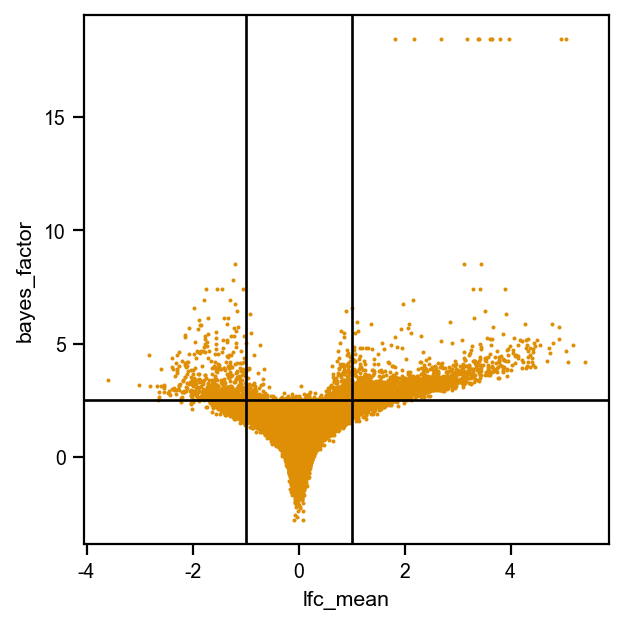

Fezf2-1


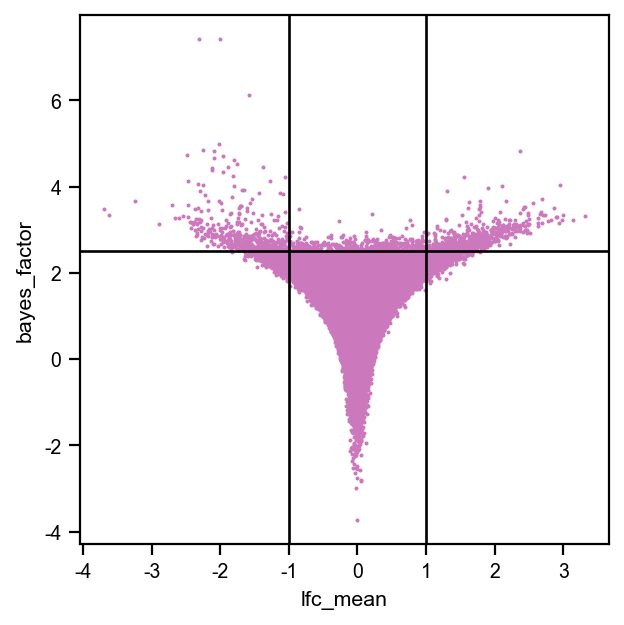

Aire-2


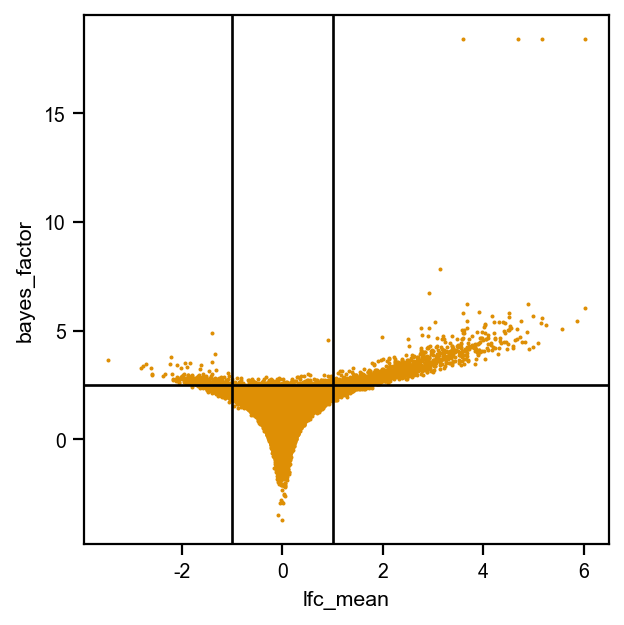

Fezf2-2


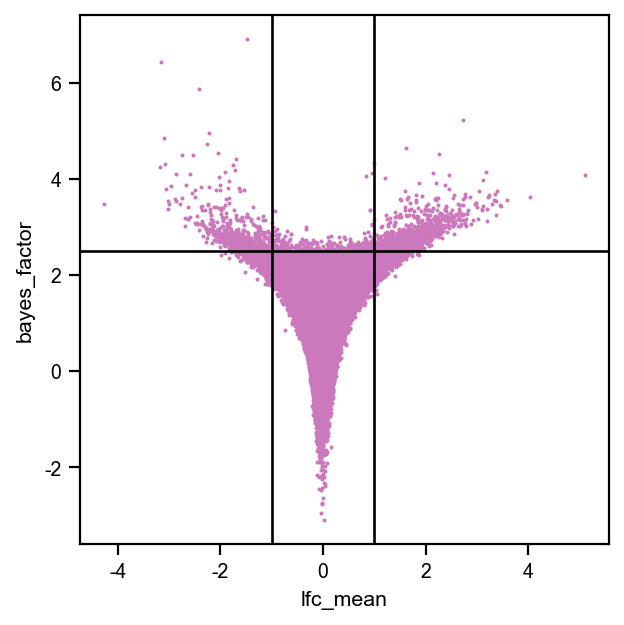

In [97]:
detected_genes = {}
filtered_genes = {}
for key, all_gene in all_genes.items():
    print(key)
    genotype, sample = key.split("-")
    if genotype == "Aire":
        color=cmap[1]
    else:
        color=cmap[4]
    subset_data = adata[adata.obs.batch.str.contains(genotype) & (adata.obs["sample"] == sample)]
    detected_gene, filtered_gene = filter_scvi_de_genes(
        adata=subset_data,
        cell_type_key="subclustered",
        expression_layer="scVI_normalized",
        df=all_gene,
        bayes_thresh=2.5,
        lfc_thresh=1,
        nonzero_thresh=0.05,
        percentile=0.99,
        peak_expression_thresh=0.5,
        color=color,
        save_path=f"../../analysis/genotype_DE/{key}_filtering.pdf"
    )
    detected_genes[key] = detected_gene
    filtered_genes[key] = filtered_gene

## WT DE

In [14]:
all_genes_WT = {}
for genotype in ["Aire", "Fezf2"]:
    data = adata[adata.obs.batch.str.contains(f"{genotype}_WT")]
    print(f"{genotype}")
    all_gene = scvi_cell_type_de(
        adata=data,
        cell_type_key="subclustered",
        group_key="sample",
        condition_group="1",
        control_group="2",
        min_cells=30,
    )
    all_genes_WT[genotype] = all_gene
    print()

Aire
Gut/Liver
Tuft1
Aire-stage
Immature MEC - Ccl21
Mcell
Tuft2
Ciliated
Immature MEC - Zeb1
Lung, basal
Skin, keratinized
Skin, basal
Goblet
Immature MEC - Bcam had too few cells in at least one group, skipping
TA MEC
Neuroendocrine
adult cTEC
Ionocyte had too few cells in at least one group, skipping

Fezf2
Gut/Liver
Tuft2
Immature MEC - Ccl21
Aire-stage
adult cTEC
Mcell
Neuroendocrine
Lung, basal
Immature MEC - Bcam
Skin, keratinized had too few cells in at least one group, skipping
Immature MEC - Zeb1
Tuft1
TA MEC
Ciliated
Goblet
Skin, basal
Ionocyte had too few cells in at least one group, skipping



Aire


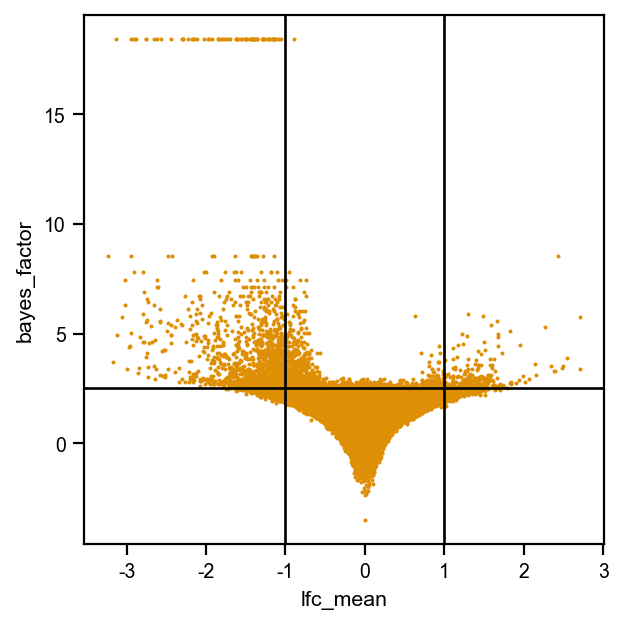

Fezf2


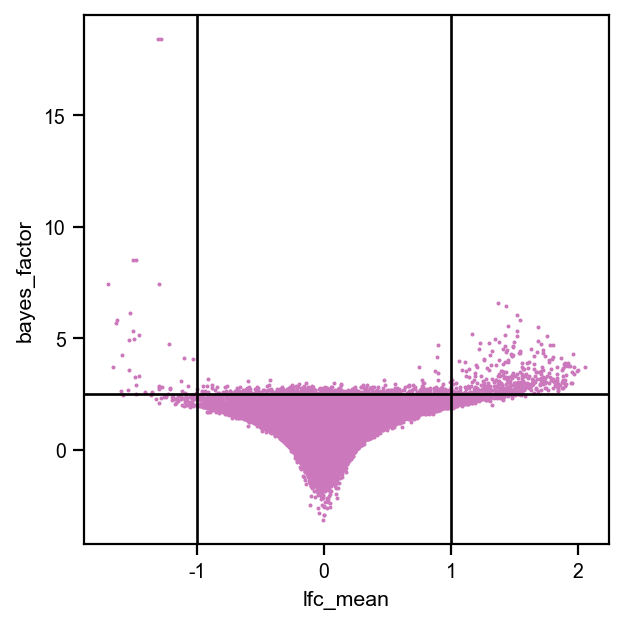

In [98]:
detected_genes_WT = {}
filtered_genes_WT = {}
for key, all_gene in all_genes_WT.items():
    print(key)
    if key == "Aire":
        color=cmap[1]
    else:
        color=cmap[4]
    subset_data = adata[adata.obs.batch.str.contains(f"{key}_WT")]
    detected_gene, filtered_gene = filter_scvi_de_genes(
        adata=subset_data,
        cell_type_key="subclustered",
        expression_layer="scVI_normalized",
        df=all_gene,
        bayes_thresh=2.5,
        lfc_thresh=1,
        nonzero_thresh=0.05,
        percentile=0.99,
        peak_expression_thresh=0.5,
        color=color,
    )
    detected_genes_WT[key] = detected_gene
    filtered_genes_WT[key] = filtered_gene

In [99]:
for key, filtered_gene in filtered_genes.items():
    WT_filtered = filtered_genes_WT[key.split("-")[0]]
    filtered_gene = filtered_gene[~filtered_gene.gene.isin(WT_filtered.gene)]

## KO DE

In [17]:
all_genes_KO = {}
for genotype in ["Aire", "Fezf2"]:
    data = adata[adata.obs.genotype == f"{genotype}_KO"]
    print(f"{genotype}")
    all_gene = scvi_cell_type_de(
        adata=data,
        cell_type_key="subclustered",
        group_key="sample",
        condition_group="1",
        control_group="2",
        min_cells=30,
    )
    all_genes_KO[genotype] = all_gene
    print()

Aire
Aire-stage
TA MEC
Immature MEC - Zeb1
Tuft2
Gut/Liver
Immature MEC - Ccl21
Neuroendocrine
adult cTEC
Tuft1
Lung, basal
Skin, basal
Goblet
Mcell
Skin, keratinized had too few cells in at least one group, skipping
Immature MEC - Bcam had too few cells in at least one group, skipping
Ciliated had too few cells in at least one group, skipping
Ionocyte had too few cells in at least one group, skipping

Fezf2
Immature MEC - Ccl21
Aire-stage
TA MEC
Immature MEC - Zeb1
Immature MEC - Bcam
adult cTEC
Goblet
Lung, basal
Gut/Liver
Neuroendocrine
Skin, keratinized
Tuft2
Mcell
Skin, basal
Ionocyte had too few cells in at least one group, skipping
Ciliated had too few cells in at least one group, skipping
Tuft1 had too few cells in at least one group, skipping



Aire


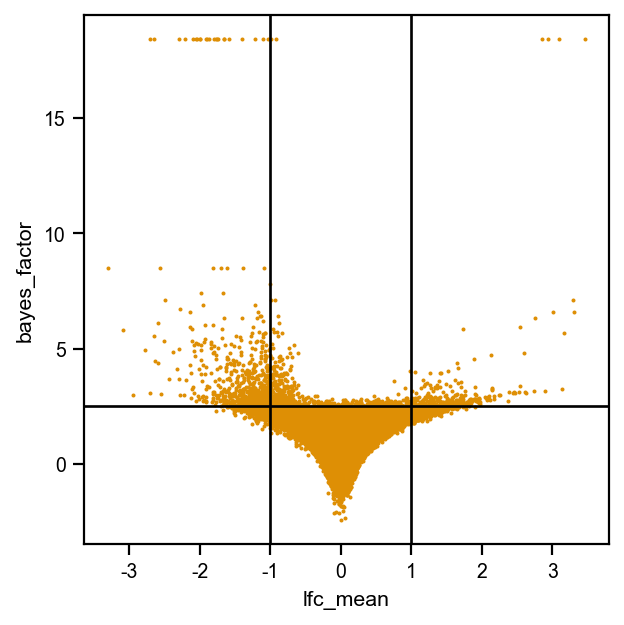

Fezf2


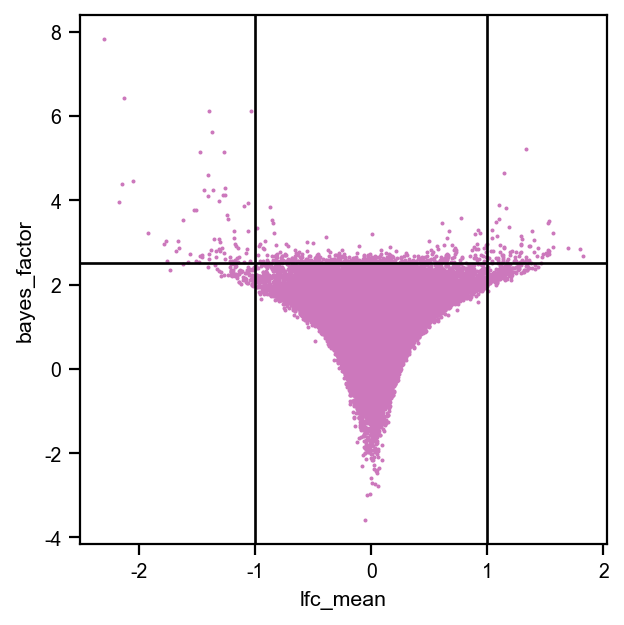

In [100]:
detected_genes_KO = {}
filtered_genes_KO = {}
for key, all_gene in all_genes_KO.items():
    print(key)
    if key == "Aire":
        color=cmap[1]
    else:
        color=cmap[4]
    subset_data = adata[adata.obs.genotype == f"{key}_KO"]
    detected_gene, filtered_gene = filter_scvi_de_genes(
        adata=subset_data,
        cell_type_key="subclustered",
        expression_layer="scVI_normalized",
        df=all_gene,
        bayes_thresh=2.5,
        lfc_thresh=1,
        nonzero_thresh=0.05,
        percentile=0.99,
        peak_expression_thresh=0.5,
        color=color,
    )
    detected_genes_KO[key] = detected_gene
    filtered_genes_KO[key] = filtered_gene

In [101]:
for key, filtered_gene  in filtered_genes.items():
    KO_filtered = filtered_genes_KO[key.split("-")[0]]
    filtered_gene = filtered_gene[~filtered_gene.gene.isin(KO_filtered.gene)]

## Take intersection and average

In [102]:
averaged_genes = {}

for genotype in ["Aire", "Fezf2"]:

    genotype_averaged = {}
    for cell_type in filtered_genes[f"{genotype}-1"].cell_type.unique():
        # Get sample data for genotype
        sample_1 = filtered_genes[f"{genotype}-1"].copy()
        sample_2 = filtered_genes[f"{genotype}-2"].copy()
        # Subset on current cell type
        sample_1 = sample_1[sample_1.cell_type == cell_type].sort_index()
        sample_2 = sample_2[sample_2.cell_type == cell_type].sort_index()
        # Subset on genes that are DE in both samples
        sample_1 = sample_1[sample_1.gene.isin(sample_2.gene)]
        sample_2 = sample_2[sample_2.gene.isin(sample_1.gene)]
        # Subset on genes that have same direction of effect in both samples
        mask = np.sign(sample_1["lfc_mean"]) == np.sign(sample_2["lfc_mean"])
        if sum(~mask) > 0:
            print(f"{genotype}-{cell_type}: {sum(~mask)} genes with discrepancies across samples")
        sample_1 = sample_1[mask]
        sample_2 = sample_2[mask]
        # Merge samples
        combined = pd.concat([sample_1, sample_2]).reset_index(drop=True)
        # Average stats across samples
        first_cols = ["gene", "cell_type", "comparison", 'group1', 'group2', "sample"]
        agg_dict = {}
        for column in combined.columns:
            if column in first_cols:
                agg_dict[column] = "first"
            else:
                agg_dict[column] = "mean"

        combined = combined.groupby("gene").agg(agg_dict)
        combined.index = combined.index + "_" + cell_type
        combined = combined.rename_axis(index={"gene": "gene_celltype"})
        genotype_averaged[cell_type] = combined
    # Combine all cell type DE dataframes for the current genotype
    averaged_genes[genotype] = pd.concat(genotype_averaged.values())

Aire-Aire-stage: 2 genes with discrepancies across samples
Aire-Goblet: 2 genes with discrepancies across samples
Aire-Mcell: 2 genes with discrepancies across samples
Aire-Gut/Liver: 1 genes with discrepancies across samples
Aire-adult cTEC: 1 genes with discrepancies across samples
Aire-Neuroendocrine: 1 genes with discrepancies across samples
Aire-Tuft2: 1 genes with discrepancies across samples


## Take max/min effect cell type for each gene

In [103]:
for genotype in ["Aire", "Fezf2"]:
    genotype_data = averaged_genes[genotype]
    averaged_genes[f"{genotype}_max_LFC"] = genotype_data.loc[genotype_data.groupby("gene")["abs_lfc"].idxmax()]
    averaged_genes[f"{genotype}_min_LFC"] = genotype_data.loc[genotype_data.groupby("gene")["abs_lfc"].idxmin()]

## Sample reproducibility

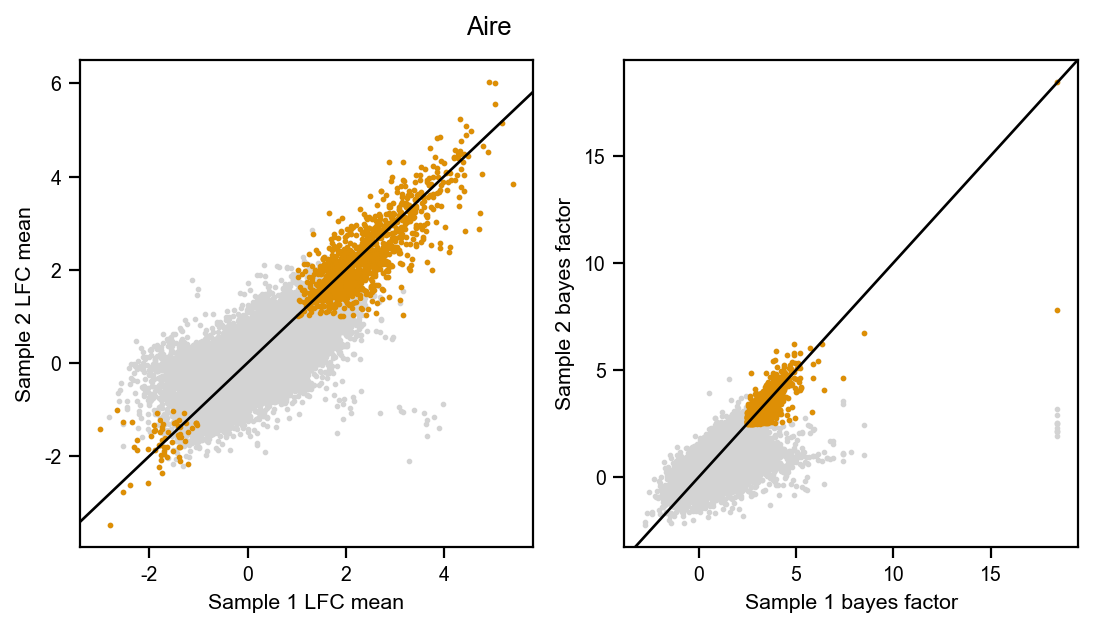

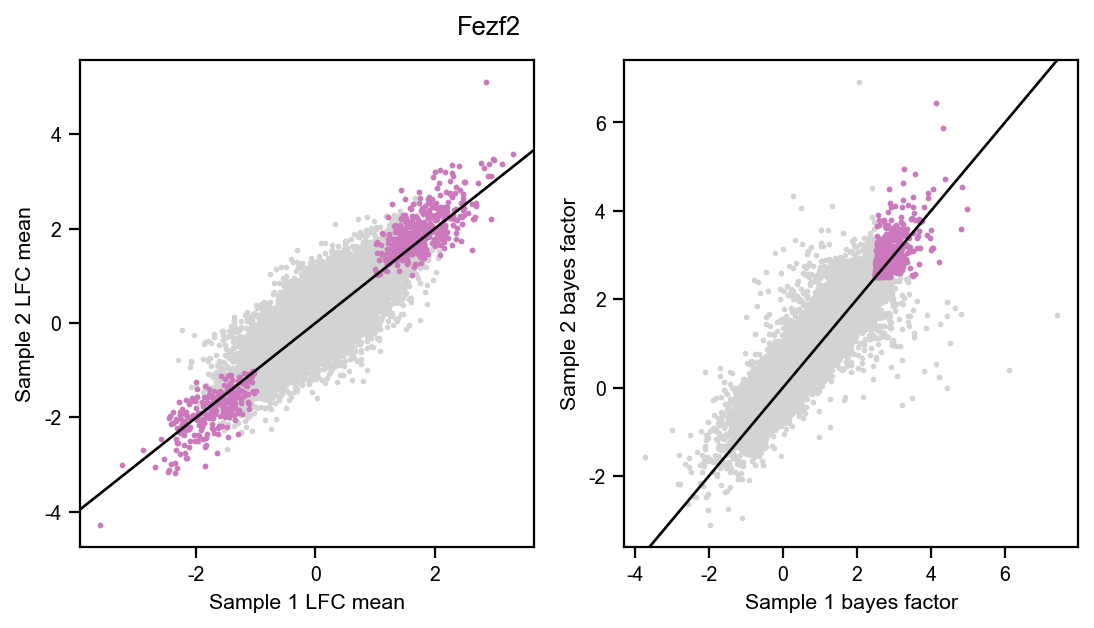

In [104]:
for genotype in ["Aire", "Fezf2"]:
    sample_1 = detected_genes[f"{genotype}-1"]
    sample_2 = detected_genes[f"{genotype}-2"]
    sample_1 = sample_1[sample_1.index.isin(sample_2.index)]
    sample_2 = sample_2[sample_2.index.isin(sample_1.index)]
    # Subset on filtered gene/cell_type combinations
    sample_1_filtered = sample_1.loc[averaged_genes[genotype].index]
    sample_2_filtered = sample_2.loc[averaged_genes[genotype].index]
    if genotype == "Aire":
        color=cmap[1]
    else:
        color=cmap[4]
    
    fig = plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    ax = plt.scatter(
        x=sample_1.lfc_mean,
        y=sample_2.lfc_mean,
        s=3,
        color="lightgrey",
        rasterized=True
    )
    ax = plt.scatter(
        x=sample_1_filtered.lfc_mean,
        y=sample_2_filtered.lfc_mean,
        s=3,
        color=color,
        rasterized=True
    )
    plt.axline((0, 0), slope=1, c="black")
    plt.xlabel("Sample 1 LFC mean")
    plt.ylabel("Sample 2 LFC mean")
    
    plt.subplot(1,2,2)
    ax = plt.scatter(
        x=sample_1.bayes_factor,
        y=sample_2.bayes_factor,
        s=3,
        color="lightgrey",
        rasterized=True
    )
    ax = plt.scatter(
        x=sample_1_filtered.bayes_factor,
        y=sample_2_filtered.bayes_factor,
        s=3,
        color=color,
        rasterized=True
    )
    plt.axline((0, 0), slope=1, c="black")
    plt.xlabel("Sample 1 bayes factor")
    plt.ylabel("Sample 2 bayes factor")
    
    plt.suptitle(genotype)
    plt.savefig(f"../../analysis/genotype_DE/{genotype}_sample_reproducibility.svg", dpi=600, bbox_inches="tight")
    plt.show()

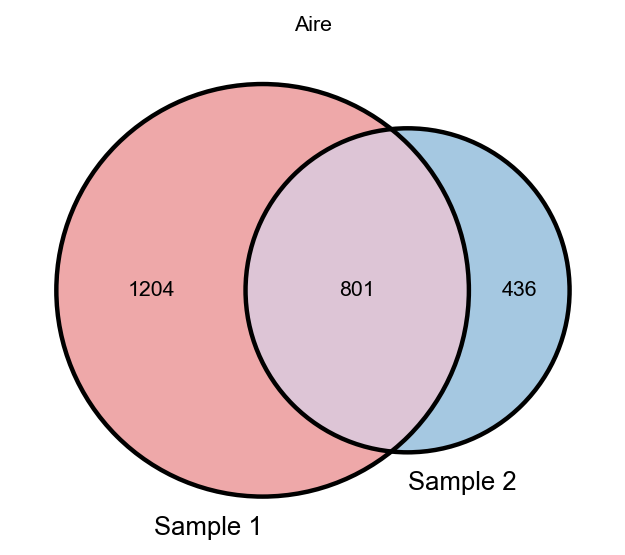

Aire % shared: 32.81


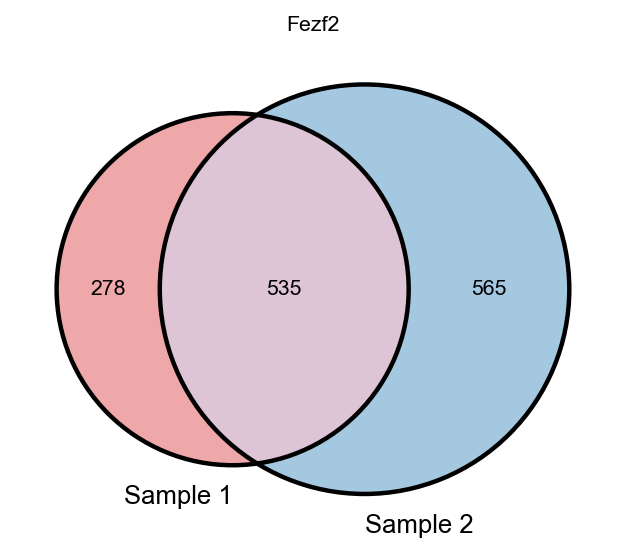

Fezf2 % shared: 38.82


In [105]:
for genotype in ["Aire", "Fezf2"]:
    both_genes = averaged_genes[genotype].gene.unique()
    sample_1 = filtered_genes[f"{genotype}-1"]
    sample_2 = filtered_genes[f"{genotype}-2"]

    sample_1_genes = {i for i in sample_1.gene if i not in both_genes}
    sample_2_genes = {i for i in sample_2.gene if i not in both_genes}
    
    venn2(
        subsets = (len(sample_1_genes), len(sample_2_genes), len(both_genes)), 
        set_labels = ('Sample 1', 'Sample 2'),
        set_colors = ["tab:red", "tab:blue"]
    )
    venn2_circles(
        subsets = (len(sample_1_genes), len(sample_2_genes), len(both_genes)), 
    )
    plt.title(genotype)
    plt.tight_layout()
    plt.savefig(f"../../analysis/genotype_DE/{genotype}_sample_overlap.pdf")
    plt.show()
    print(f"{genotype} % shared: {round(len(both_genes)/(len(both_genes)+len(sample_1_genes)+len(sample_2_genes))*100, 2)}")

# Save dictionaries

In [106]:
with open('../../analysis/genotype_DE/dictionaries/averaged_genes.pkl', 'wb') as handle:
    pickle.dump(averaged_genes, handle)

with open('../../analysis/genotype_DE/dictionaries/filtered_genes.pkl', 'wb') as handle:
    pickle.dump(filtered_genes, handle)
    
with open('../../analysis/genotype_DE/dictionaries/detected_genes.pkl', 'wb') as handle:
    pickle.dump(detected_genes, handle)
    
with open('../../analysis/genotype_DE/dictionaries/all_genes.pkl', 'wb') as handle:
    pickle.dump(all_genes, handle)

# Load dictionaries

In [8]:
with open('../../analysis/genotype_DE/dictionaries/averaged_genes.pkl', 'rb') as handle:
    averaged_genes = pickle.load(handle)

with open('../../analysis/genotype_DE/dictionaries/filtered_genes.pkl', 'rb') as handle:
    filtered_genes = pickle.load(handle)
    
with open('../../analysis/genotype_DE/dictionaries/detected_genes.pkl', 'rb') as handle:
    detected_genes = pickle.load(handle)
    
with open('../../analysis/genotype_DE/dictionaries/all_genes.pkl', 'rb') as handle:
    all_genes = pickle.load(handle)

# Save gene lists

In [108]:
averaged_genes["Fezf2"].to_csv("../../analysis/genotype_DE/max_LFC_csv/Fezf2_DE_genes.csv")
averaged_genes["Aire"].to_csv("../../analysis/genotype_DE/max_LFC_csv/Aire_DE_genes.csv")

# Num regulated genes comparison

In [109]:
gene_directions = {}
for genotype in ["Aire", "Fezf2"]:
    data = averaged_genes[genotype]
    genotype_directions = {"multidirectional": [], "induced": [], "repressed": []}
    for gene in data.gene.unique():
        gene_data = data[data.gene == gene]
        if sum(gene_data.lfc_mean < 0) > 0 and sum(gene_data.lfc_mean > 0) > 0:
            genotype_directions["multidirectional"].append(gene)
        else:
            if sum(gene_data.lfc_mean < 0) > 0:
                genotype_directions["repressed"].append(gene)
            else:
                genotype_directions["induced"].append(gene)
    gene_directions[genotype] = genotype_directions

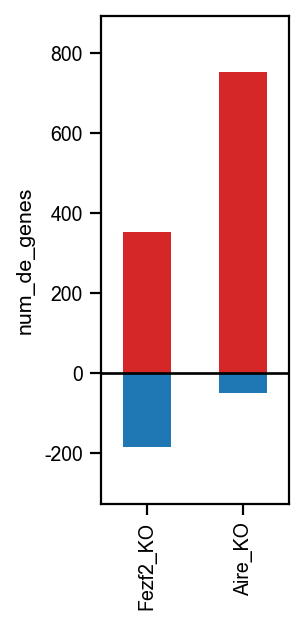

In [110]:
plotData = {}
plotData["induced"] = [
    len(gene_directions["Fezf2"]["induced"]) + len(gene_directions["Fezf2"]["multidirectional"]),
    len(gene_directions["Aire"]["induced"]) + len(gene_directions["Aire"]["multidirectional"])
]
plotData["repressed"] = [
    len(gene_directions["Fezf2"]["repressed"]) + len(gene_directions["Aire"]["multidirectional"]),
    len(gene_directions["Aire"]["repressed"]) + len(gene_directions["Aire"]["multidirectional"])
]

plotData = pd.DataFrame(plotData, index=["Fezf2_KO", "Aire_KO"])

fig=plt.figure(figsize=(2,4))
plt.bar(x=plotData.index, height=plotData.induced, color='tab:red', width=0.5)
plt.bar(x=plotData.index, height=-plotData.repressed, color='tab:blue', width=0.5)
plt.xticks([0,1], plotData.index, rotation='vertical')
plt.ylabel("num_de_genes")
plt.axhline(y=0, c="black")
plt.margins(0.15)
plt.tight_layout()
plt.savefig(f"../../analysis/genotype_DE/num_de_genes.pdf")
plt.show()

In [111]:
print(f"Aire repressed: {plotData.repressed.tolist()[1]}")
print(f"Aire induced: {plotData.induced.tolist()[1]}")
print(f"Fezf2 repressed: {plotData.repressed.tolist()[0]}")
print(f"Fezf2 induced: {plotData.induced.tolist()[0]}")

Aire repressed: 50
Aire induced: 753
Fezf2 repressed: 185
Fezf2 induced: 352


# Fezf2 regulated genes

In [112]:
fezf2_regulated_genes_data=pd.read_csv("../../Fezf2_microarray_DE_genes.csv", index_col=0)
fezf2_regulated_genes_data["-10logp"] = -1*np.log10(fezf2_regulated_genes_data["adj.P.Val"])

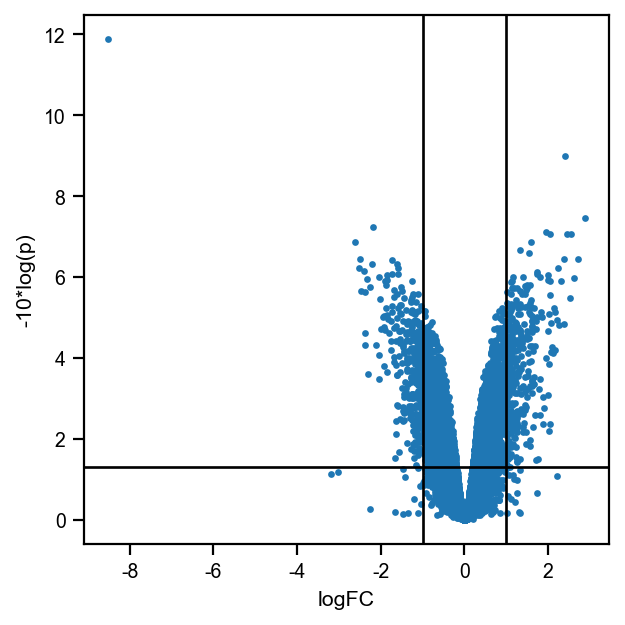

In [113]:
plt.scatter(
    x=fezf2_regulated_genes_data.logFC,
    y=fezf2_regulated_genes_data["-10logp"],
    rasterized=True,
    s=5
)
plt.xlabel("logFC")
plt.ylabel("-10*log(p)")
plt.axhline(y=-1*np.log10(0.05), c="black")
plt.axvline(x=-1, c="black")
plt.axvline(x=1, c="black")
plt.tight_layout()
plt.show()

In [114]:
fezf2_regulated_genes_data = fezf2_regulated_genes_data[fezf2_regulated_genes_data["adj.P.Val"] < 0.05]
fezf2_regulated_genes_data = fezf2_regulated_genes_data[abs(fezf2_regulated_genes_data.logFC) > 2]
fezf2_regulated_genes_data = fezf2_regulated_genes_data[fezf2_regulated_genes_data.symbols != "Fezf2"]

In [115]:
(fezf2_regulated_genes_data.drop_duplicates(subset="symbols").logFC > 0).sum()

26

In [116]:
(fezf2_regulated_genes_data.drop_duplicates(subset="symbols").logFC < 0).sum()

17

In [117]:
fezf2_regulated_genes = fezf2_regulated_genes_data.symbols.unique()

In [118]:
for genotype in ["Aire", "Fezf2"]:
    averaged_genes[f'{genotype}_max_LFC']["Fezf2_regulated"] = averaged_genes[f'{genotype}_max_LFC'].gene.isin(fezf2_regulated_genes)

In [119]:
averaged_genes['Aire_max_LFC'].Fezf2_regulated.sum()

9

In [120]:
averaged_genes['Fezf2_max_LFC'].Fezf2_regulated.sum()

27

# Volcano plots

In [15]:
def volcanoplot(df, x, y, annotate_genes=None, save_path=None, annotate_genes_colors=None, *args, **kwargs):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        linewidth=0.25,
        edgecolor="black",
        *args, **kwargs
    )
    for j,gene_list in enumerate(annotate_genes):
        if annotate_genes_colors is not None:
            color = annotate_genes_colors[j]
        else:
            color = "black"
        annotated_genes = df[df.gene.isin(gene_list)]
        texts = []
        for i, row in annotated_genes.iterrows():
            texts.append(
                plt.text(
                    row[x],
                    row[y],
                    row['gene'],
                    ha='center',
                    va='bottom',
                    fontsize=8, 
                    color=color,
                )
            )
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color=color))
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

## Max LFC

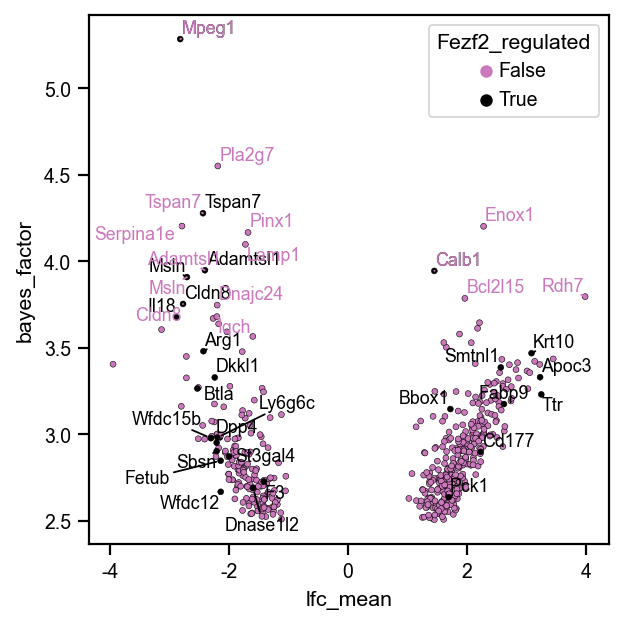

In [122]:
gene_lists = [
    fezf2_regulated_genes,
    averaged_genes["Fezf2_max_LFC"].sort_values(by="bayes_factor", ascending=False).head(15).gene
]
averaged_genes["Fezf2_max_LFC"] = averaged_genes["Fezf2_max_LFC"].sort_values(by="Fezf2_regulated") 
volcanoplot(
    df=averaged_genes["Fezf2_max_LFC"],
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", cmap[4]],
    hue="Fezf2_regulated",
    s=7,
    palette=[cmap[4], "black"],
    save_path="../../analysis/genotype_DE/fezf2_de_genes.pdf"
)

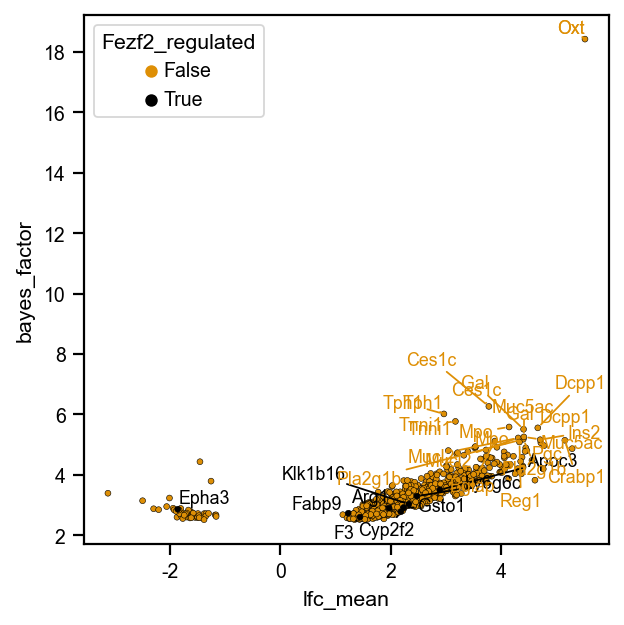

In [123]:
gene_lists = [
    fezf2_regulated_genes,
    averaged_genes["Aire_max_LFC"].sort_values(by="bayes_factor", ascending=False).head(15).gene,
    averaged_genes["Aire_max_LFC"][averaged_genes["Aire_max_LFC"].lfc_mean > 0].sort_values(by="bayes_factor", ascending=False).head(10).gene,
]
averaged_genes["Aire_max_LFC"] = averaged_genes["Aire_max_LFC"].sort_values(by="Fezf2_regulated") 
volcanoplot(
    df=averaged_genes["Aire_max_LFC"],
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", cmap[1], cmap[1]],
    hue="Fezf2_regulated",
    s=7,
    palette=[cmap[1], "black"],
    save_path="../../analysis/genotype_DE/aire_de_genes.pdf"
)

## WT vs KO lung basal/goblet

In [12]:
cell_type_de = averaged_genes["Fezf2"]
cell_type_de[cell_type_de.cell_type == "Goblet"].sort_values(by="lfc_mean").head(50)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2,cell_type,gene,abs_lfc,expression_0.99
gene_celltype,,,,,,,,,,,,,,,,,,,,,
Orm3_Goblet,0.9514,0.0486,2.975334,0.000003,0.000019,0.0,0.25,-2.511909,-2.564379,2.260214,...,0.000000,0.220236,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Orm3,2.511909,1.101280
Cysrt1_Goblet,0.9559,0.0441,3.077326,0.000058,0.000210,0.0,0.25,-2.286408,-2.314220,3.961871,...,0.523470,2.510233,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Cysrt1,2.286408,13.114802
Il18_Goblet,0.9401,0.0599,2.755648,0.000047,0.000313,0.0,0.25,-2.268951,-2.241228,2.033693,...,0.343086,3.148545,0.5,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Il18,2.268951,15.061807
Crct1_Goblet,0.9548,0.0452,3.072462,0.000095,0.000421,0.0,0.25,-2.242624,-2.121615,3.416075,...,2.094352,9.532039,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Crct1,2.242624,36.274596
Sbsn_Goblet,0.9480,0.0520,2.903583,0.000546,0.001959,0.0,0.25,-2.203078,-2.306401,2.828753,...,5.654391,25.737153,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Sbsn,2.203078,96.558506
Ly6g6c_Goblet,0.9517,0.0483,2.982156,0.000171,0.000665,0.0,0.25,-2.191134,-2.260245,3.145820,...,1.709052,7.412036,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Ly6g6c,2.191134,27.219256
Ccr3_Goblet,0.9522,0.0478,3.003196,0.000016,0.000055,0.0,0.25,-2.190439,-2.317711,2.989877,...,0.020530,0.522228,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Ccr3,2.190439,2.198484
Sprr2f_Goblet,0.9489,0.0511,2.921842,0.000019,0.000083,0.0,0.25,-2.170026,-2.154973,1.981987,...,0.541170,3.097298,1.0,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Sprr2f,2.170026,5.971078
Cst6_Goblet,0.9439,0.0561,2.825820,0.000590,0.002256,0.0,0.25,-2.008212,-2.069192,2.212757,...,7.085963,14.623396,0.5,WT vs Fezf2_KO,WT,Fezf2_KO,Goblet,Cst6,2.008212,110.015361


In [24]:
annotate_genes

['Sox2',
 'Serpina1e',
 'Ano1',
 'Calm4',
 'Il36a',
 'Cysrt1',
 'Crct1',
 'Cp',
 'Atp6v1b1',
 'Scgb3a2',
 'C4b',
 'Cyp2d10',
 'Ccr3',
 'Krt6b',
 'Epas1',
 'Ly6g6c',
 'Cnfn',
 'Orm3',
 'Kcnk5',
 'Plaur',
 'Snrpn',
 'Thbs1',
 'Sprr2f',
 'Trf',
 'Orm2',
 'Sbsn']

Goblet


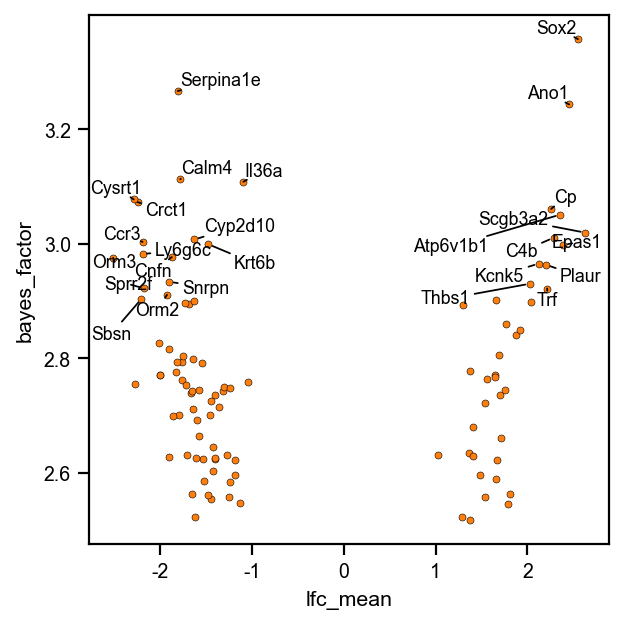

Lung, basal


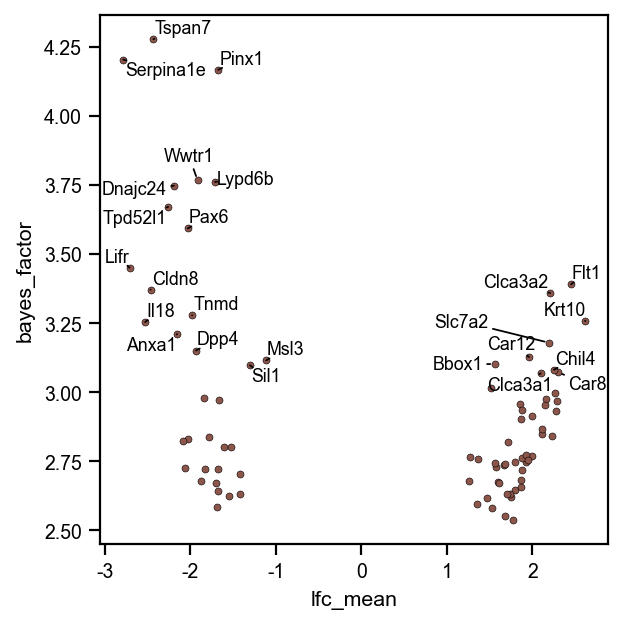

In [31]:
for cell_type in ["Goblet", "Lung, basal"]:
    print(cell_type)
    cell_type_de = averaged_genes["Fezf2"]
    cell_type_de = cell_type_de[cell_type_de.cell_type == cell_type]

    annotate_genes = cell_type_de.sort_values(by="bayes_factor", ascending=False).head(25).gene.tolist()
    annotate_genes.append("Sbsn")
    
    if cell_type == "Lung, basal":
        color = new_tab20[8]
    else:
        color = new_tab20[2]

    volcanoplot(
        df=cell_type_de,
        x="lfc_mean",
        y="bayes_factor",
        annotate_genes=[annotate_genes],
        annotate_genes_colors=["black", "black", "black"],
        color=color,
        s=10,
        save_path=f"../../analysis/genotype_DE/WT_KO_{cell_type}_de.pdf"
    )

# ChIP data

In [125]:
server = biomart.BiomartServer('http://www.ensembl.org/biomart')         
mart = server.datasets['mmusculus_gene_ensembl']                            
attributes = ['mgi_symbol', 'ensembl_gene_id']                               
response = mart.search({'attributes': attributes})                          
data = response.raw.data.decode('ascii')                                    
ensembl_to_genesymbol = {}                                                                                               
for line in data.splitlines():                                              
    line = line.split('\t')                                                                                              
    gene_symbol = line[0]                                                   
    ensembl_gene = line[1]                                                                                           
    if len(gene_symbol) > 0:
        ensembl_to_genesymbol[ensembl_gene] = gene_symbol                                  

In [133]:
all_genes_chip_signal = pd.read_csv("../../analysis/ChIP_seq/all_genes_matrix.tsv", sep="\t", header=None)

symbol_dict = {}
for gene_id in all_genes_chip_signal[3]:
    if gene_id in ensembl_to_genesymbol.keys():
        symbol_dict[gene_id] = ensembl_to_genesymbol[gene_id]
    else:
        symbol_dict[gene_id] = gene_id
all_genes_chip_signal[3] = all_genes_chip_signal[3].replace(symbol_dict)

all_genes_chip_signal.index = all_genes_chip_signal[3]

for i in range(0,6):
    if i in all_genes_chip_signal.columns:
        del all_genes_chip_signal[i]
        
all_genes_chip_signal = all_genes_chip_signal.T
all_genes_chip_signal["sample"] = ["input"]*2000 + ["Fezf2_ChIP"]*2000

all_genes_chip_signal_grouped_max = all_genes_chip_signal.groupby("sample").max().T
all_genes_chip_signal_grouped_mean = all_genes_chip_signal.groupby("sample").mean().T
del all_genes_chip_signal["sample"]
all_genes_chip_signal = all_genes_chip_signal.T

all_genes_chip_signal["peak_LFC"] = np.log2(all_genes_chip_signal_grouped_max.Fezf2_ChIP/all_genes_chip_signal_grouped_max.input)
all_genes_chip_signal["mean_LFC"] = np.log2(all_genes_chip_signal_grouped_mean.Fezf2_ChIP/all_genes_chip_signal_grouped_mean.input)

/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


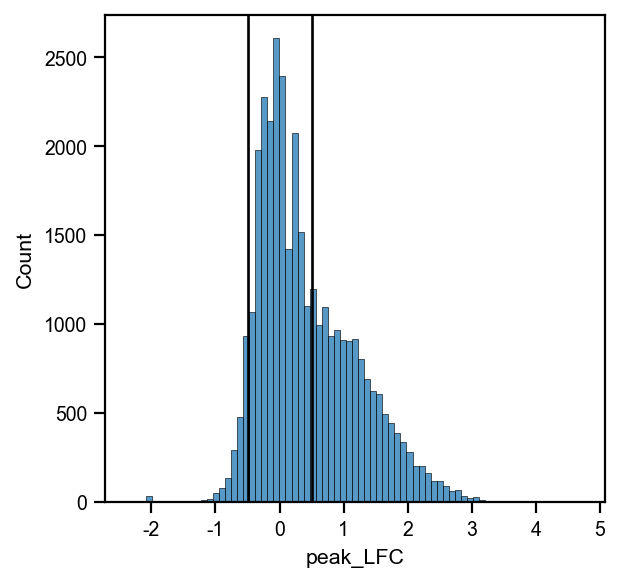

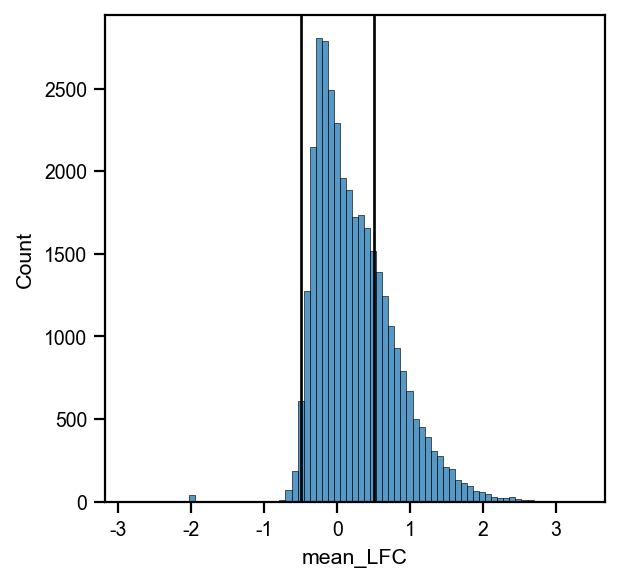

In [134]:
sns.histplot(all_genes_chip_signal["peak_LFC"], color="tab:blue", bins=75)

plt.axvline(x=0.5, c="black")
plt.axvline(x=-0.5, c="black")
plt.show()

sns.histplot(all_genes_chip_signal["mean_LFC"], color="tab:blue", bins=75)

plt.axvline(x=0.5, c="black")
plt.axvline(x=-0.5, c="black")
plt.show()

In [135]:
all_genes_chip_signal_filtered = all_genes_chip_signal[all_genes_chip_signal.peak_LFC > 0.5].copy()
all_genes_chip_signal_filtered = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.mean_LFC > 0.5]
expected_fraction = all_genes_chip_signal_filtered.shape[0]/all_genes_chip_signal.shape[0]

In [137]:
all_genes_chip_signal_filtered.to_csv("../../analysis/ChIP_seq/Fezf2_bound.csv")

In [161]:
fezf_de_up = gene_directions["Fezf2"]["induced"] + gene_directions["Fezf2"]["multidirectional"]
pd.DataFrame(fezf_de_up, columns=["gene"]).to_csv("../../analysis/ChIP_seq/Fezf2_de_up.csv")
fezf_de_down = gene_directions["Fezf2"]["repressed"] + gene_directions["Fezf2"]["multidirectional"]
pd.DataFrame(fezf_de_down, columns=["gene"]).to_csv("../../analysis/ChIP_seq/Fezf2_de_down.csv")
fezf_de = set(fezf_de_up + fezf_de_down)
aire_de_up = gene_directions["Aire"]["induced"] + gene_directions["Aire"]["multidirectional"]
aire_de_down = gene_directions["Aire"]["repressed"] + gene_directions["Aire"]["multidirectional"]
aire_de = set(aire_de_up + aire_de_down)

In [139]:
real_fezf2_de_frac = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(fezf_de)].shape[0]/len(fezf_de)
fezf2_down_chip = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(fezf_de_down)]
fezf2_up_chip = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(fezf_de_up)]

In [140]:
real_aire_de_frac = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(aire_de)].shape[0]/len(aire_de)
aire_down_chip = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(aire_de_down)]
aire_up_chip = all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(aire_de_up)]

In [142]:
fezf2_de_frac = []
aire_de_frac = []
num_iter = 5000
random.seed(42)
for i in range(0,num_iter):
    fezf_de_shuffled = random.sample(all_genes_chip_signal.index.tolist(), len(fezf_de))
    aire_de_shuffled = random.sample(all_genes_chip_signal.index.tolist(), len(aire_de))
    
    fezf2_de_frac.append(
        all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(fezf_de_shuffled)].shape[0]/len(fezf_de_shuffled)
    )
    aire_de_frac.append(
        all_genes_chip_signal_filtered[all_genes_chip_signal_filtered.index.isin(aire_de_shuffled)].shape[0]/len(aire_de_shuffled)
    )

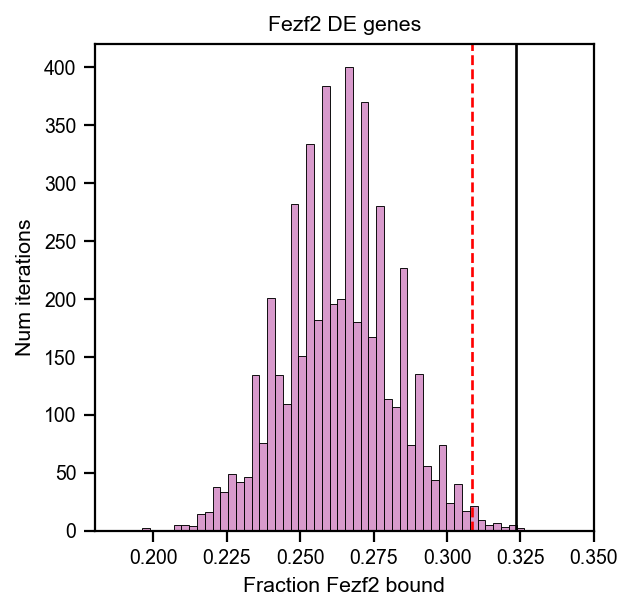

In [150]:
sns.histplot(
    fezf2_de_frac,
    bins=50,
    color=cmap[4]
)
plt.axvline(
    real_fezf2_de_frac,
    c="black"
)
# plt.axvline(
#     expected_fraction,
#     c="grey",
#     linestyle="--"
# )
plt.axvline(
    np.quantile(fezf2_de_frac, 0.99),
    c="red",
    linestyle="--"
)
plt.ylabel("Num iterations")
plt.xlabel("Fraction Fezf2 bound")
plt.title("Fezf2 DE genes")
plt.xlim(0.18,0.35)
plt.savefig("../../analysis/genotype_DE/Fezf2_DE_chip_overlap_stats.pdf", bbox_inches="tight")
plt.show()

In [144]:
sum([i >= real_fezf2_de_frac for i in fezf2_de_frac])/num_iter

0.001

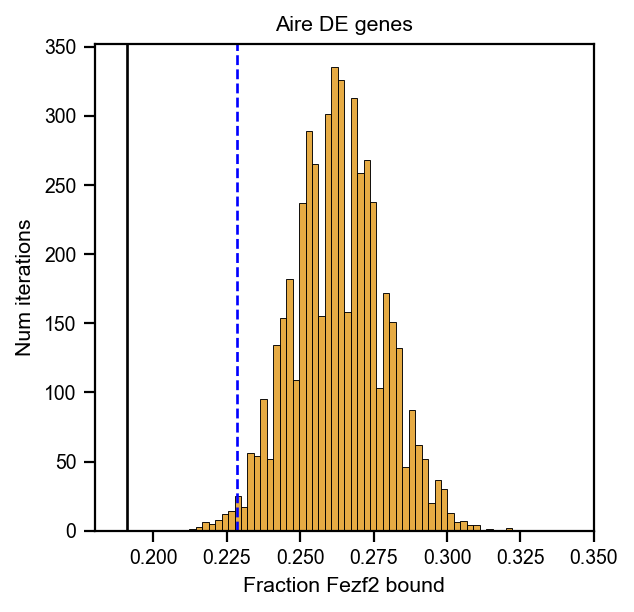

In [149]:
sns.histplot(
    aire_de_frac,
    bins=50,
    color=cmap[1]
)
plt.axvline(
    real_aire_de_frac,
    c="black"
)
# plt.axvline(
#     expected_fraction,
#     c="grey",
#     linestyle="--"
# )
plt.axvline(
    np.quantile(aire_de_frac, 0.01),
    c="blue",
    linestyle="--"
)
plt.xlabel("Fraction Fezf2 bound")
plt.ylabel("Num iterations")
plt.title("Aire DE genes")
plt.xlim(0.18,0.35)
plt.savefig("../../analysis/genotype_DE/Aire_DE_chip_overlap_stats.pdf", bbox_inches="tight")
plt.show()

In [146]:
sum([i <= real_aire_de_frac for i in aire_de_frac])/num_iter

0.0

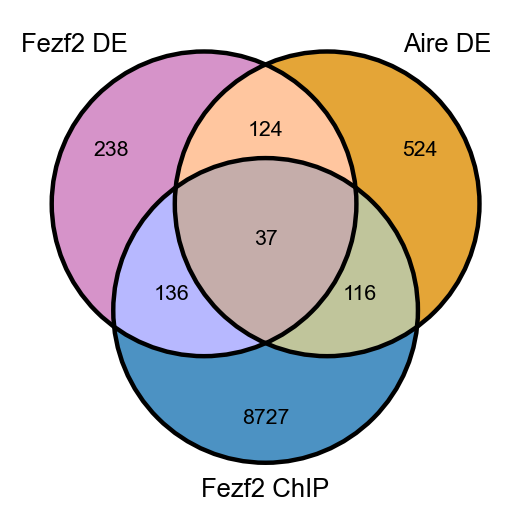

In [147]:
venn3_unweighted(
    (set(fezf_de), set(aire_de), set(all_genes_chip_signal_filtered.index)),
    set_labels=('Fezf2 DE', 'Aire DE', 'Fezf2 ChIP'),
    set_colors=(cmap[4], cmap[1], "tab:blue"),
    alpha=0.8
)
venn3_circles((1,1,1,1,1,1,1))
plt.savefig("../../analysis/genotype_DE/DE_ChIP_gene_overlap.pdf", bbox_inches="tight")
plt.show()

# KO only goblet/basal lung vs rest

## Goblet

In [151]:
goblet_de_genes = model.differential_expression(
    adata=adata[adata.obs.genotype == "Fezf2_KO"],
    groupby="subclustered",
    group1="Goblet",
    silent=True,
)

In [152]:
goblet_de_genes_filtered = goblet_de_genes[goblet_de_genes.bayes_factor > 2.5]
goblet_de_genes_filtered = goblet_de_genes_filtered[abs(goblet_de_genes_filtered.lfc_mean) > 1]
goblet_de_genes_filtered = goblet_de_genes_filtered[goblet_de_genes_filtered.non_zeros_proportion1 > 0.1]

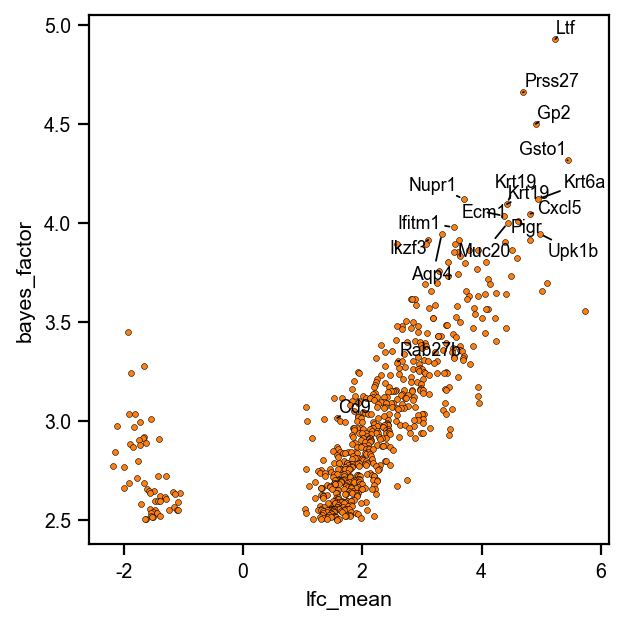

In [153]:
goblet_de_genes_filtered["gene"] = goblet_de_genes_filtered.index
gene_lists = [
    goblet_de_genes_filtered.sort_values(by="bayes_factor", ascending=False).head(15).gene,
    ["Rab27b", "Krt19", "Cd9"]
]
volcanoplot(
    df=goblet_de_genes_filtered,
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", "black"],
    color=new_tab20[2],
    s=7,
    save_path="../../analysis/genotype_DE/KO_goblet_vs_rest_de_genes.pdf"
)

## Basal lung

In [154]:
lung_de_genes = model.differential_expression(
    adata=adata[adata.obs.genotype == "Fezf2_KO"],
    groupby="subclustered",
    group1="Lung, basal",
    silent=True,
)

In [155]:
lung_de_genes_filtered = lung_de_genes[lung_de_genes.bayes_factor > 2.5]
lung_de_genes_filtered = lung_de_genes_filtered[abs(lung_de_genes_filtered.lfc_mean) > 1]
lung_de_genes_filtered = lung_de_genes_filtered[lung_de_genes_filtered.non_zeros_proportion1 > 0.1]

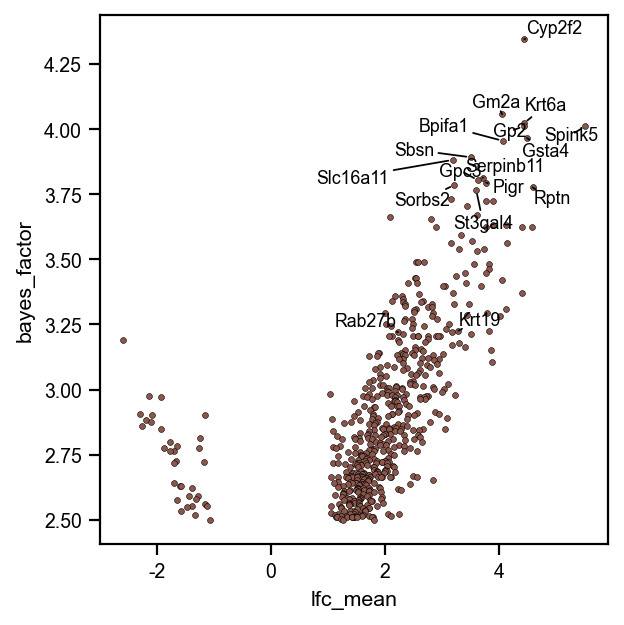

In [156]:
lung_de_genes_filtered["gene"] = lung_de_genes_filtered.index
gene_lists = [
    lung_de_genes_filtered.sort_values(by="bayes_factor", ascending=False).head(15).gene,
    ["Rab27b", "Krt19", "Cd9"]
]
volcanoplot(
    df=lung_de_genes_filtered,
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", "black"],
    color=new_tab20[8],
    s=7,
    save_path="../../analysis/genotype_DE/KO_basal_lung_vs_rest_de_genes.pdf"
)

In [158]:
pd.concat([lung_de_genes_filtered, goblet_de_genes_filtered]).reset_index().to_csv("../../analysis/genotype_DE/other_csv/Fezf2_KO_goblet_lung_vs_rest_DE.csv")